# Lab 2 Notebook

Day 2, trabajamos con el problema de pertenencia, trabajamos con movimientos propios 

Vector Point Diagram, en éste tipo de diagramas, esperamos que se comporte de manera similar debido a que están en el mismo potencial gravitacional 

ésto es astrometría, midiendo movimientos propios en arcosegundos por año, ya que son velocidades angulares.

Secundos de arco por siblo son para astrometría que se ha hecho desde la edad media, más o menos. 

Como las escalas temporales son tan grandes y como los objetos son tan lentos, asumimos que las velocidades angulares son constantes. 

Para cometas no se puede hacer, porque son rápidos. 

ést se puede descomponer en asencio recta y declinación como componenetes. 

Asumiendo que en la vía láctea se mueven con mla misma velocidad angular, los objetos de un cúmulo estan en las mismas distancias, entonces las velocidades angulares del mismo son relativamentes las mismas, y también las tangenciales. 

La relación se expresa como:

$$v_t = 4.74 \cdot \mu \cdot d$$

Donde:$v_t$: Velocidad tangencial (en km/s).$\mu$: Movimiento propio (en arcsec/año).$d$: Distancia (en pársecs).

Como tarea derivar ésto, supongo. 

Y el movimiento propio es $$\mu = \sqrt{\mu_{\alpha*}^2 + \mu_{\delta}^2}$$

En Gaia los movimientos ya llevan la corrección del coseno. Y los centroides de las estrellas van a tener velocidades angulares distintas porque están a distancias distintas. 


Hasta donde se saben, los cúmulos abiertos observados no superan los 30 pc en la vía láctea, la forma en la que modelamos ésto es debido a que el bulb es una distribución gaussiana bimodal con sigmas distintos. 

Y el campo se modela como lo mencionado como en la clase pasada. 

Después charlamos de cómo tenemos que resolver el modelo de pertenencia estelar y que vamos a escoger 0.5 como probabilibidad, tiene que dar el histograma como una U.





In [1]:
#abrimos los datos primero para cargarlos 
#estan en formato .vot

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io.votable import parse_single_table
import seaborn as sns 
import matplotlib.colors as mcolors

#cargamos los datos
#son los mismo datos utilizados para el lab anterior, pero ahora los cargamos desde un archivo .vot
table = parse_single_table("9be353af-13f0-11f1-b8e9-bc97e148b76b-O-result.vot")

#transformar la tabla en un dataframe de pandas
df = table.to_table().to_pandas()

#imprimimos las estrellas cargadas y las columnas
print(f"Total stars loaded : {len(df)}")
print(f"Columns available  : {len(df.columns)}")

#filtro de paralaje 
df_miembros = df[(df['parallax'] >= 1.5)& (df['parallax'] <= 1.7)].copy() #copiamos en un nuevo dataframe 
print(f"Stars with parallax between 1.5 and 1.7 mas : {len(df_miembros)}") #cuántas seleccionadas con el filtro de paralaje

#Encontrar el centroide

mu_apha_cluster = df_miembros['pmra'].mean()
mu_delta_cluster = df_miembros['pmdec'].mean()#promedios para los movimientos propios en ambas componentes para encontrar el centrodie

#imprimir centroide
print(f"Centroid (mu_alpha, mu_delta) : ({mu_apha_cluster:.4f}, {mu_delta_cluster:.4f}) mas/yr")

df_miembros.head()



Total stars loaded : 1894
Columns available  : 60
Stars with parallax between 1.5 and 1.7 mas : 1894
Centroid (mu_alpha, mu_delta) : (-0.7683, 0.4916) mas/yr


,SOURCE_ID,random_index,ra,dec,parallax,parallax_error,parallax_over_error,pmra,pmra_error,pmdec,...,ebpminrp_gspphot,target_id,target_ra,target_dec,target_parallax,target_pm_ra,target_pm_dec,target_radial_velocity,epoch,target_separation__deg_
0,2927009530651172480,1493830911,101.542752,-20.706708,1.506667,0.075821,19.871271,-2.438702,0.046801,8.143655,...,0.3550,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.030356
1,2927008224973258880,432544849,101.515583,-20.750996,1.687477,0.022428,75.240662,-4.487024,0.013377,-1.428956,...,NaN,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.032477
2,2927008220678979072,987731091,101.521761,-20.752418,1.640919,0.170961,9.598212,5.300414,0.104096,26.067267,...,0.2296,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.034803
3,2927009010952534400,1054834083,101.480106,-20.735266,1.563817,0.155893,10.031353,10.625169,0.092550,-4.582456,...,0.2585,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.034898
4,2927008534218797184,1280229741,101.530020,-20.754326,1.645853,0.025224,65.248566,-3.341236,0.013646,-0.988772,...,NaN,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.039135


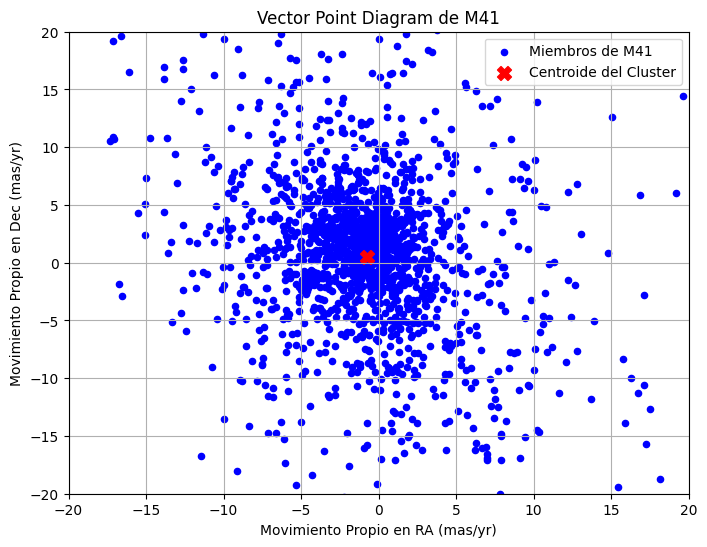

In [11]:
#vector point diagram entre .20 y 20 en ambs y con histogramas adicionales 

plt.figure(figsize=(8, 6))
plt.scatter(df_miembros['pmra'], df_miembros['pmdec'], s=20, color='blue', label='Miembros de M41')
plt.scatter(mu_alpha_cluster, mu_delta_cluster, s=100, color='red', label='Centroide del Cluster', marker='X')
plt.xlabel('Movimiento Propio en RA (mas/yr)')
plt.ylabel('Movimiento Propio en Dec (mas/yr)')
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.title('Vector Point Diagram de M41')
plt.legend()
plt.grid()
plt.show()

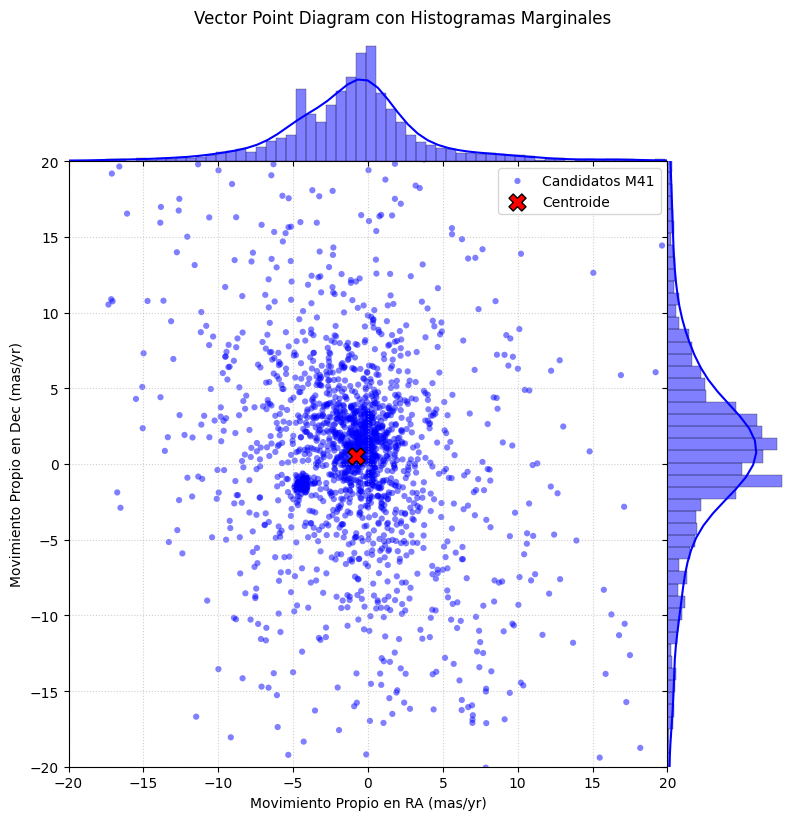

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos un JointGrid para tener control total sobre los histogramas y el scatter
g = sns.JointGrid(data=df_miembros, x='pmra', y='pmdec', space=0, height=8)

# 1. Graficamos el scatter principal en el centro
g.plot_joint(plt.scatter, s=20, color='blue', alpha=0.5, label='Candidatos M41', edgecolors='none')

# 2. Agregamos los histogramas en los márgenes
# 'fill=True' para que se vea el área bajo la curva
g.plot_marginals(sns.histplot, color='blue', kde=True, bins=200)

# 3. Marcamos el centroide del cúmulo (usando el objeto ax_joint)
g.ax_joint.scatter(mu_alpha_cluster, mu_delta_cluster, s=150, color='red', 
                   label='Centroide', marker='X', edgecolors='black', zorder=5)

# 4. Configuración de límites y etiquetas
g.ax_joint.set_xlim(-20, 20)
g.ax_joint.set_ylim(-20, 20)
g.ax_joint.set_xlabel('Movimiento Propio en RA (mas/yr)')
g.ax_joint.set_ylabel('Movimiento Propio en Dec (mas/yr)')

# Añadir rejilla y leyenda al gráfico principal
g.ax_joint.grid(linestyle=':', alpha=0.6)
g.ax_joint.legend()

plt.suptitle('Vector Point Diagram con Histogramas Marginales', y=1.02)
plt.show()

Para las suposiciones iniciales se escogen las sigmas para las bimodales para declinación y asencion recta, saln dos centroides y 4 sigmas para tner un estimación inicial. 

Uno espera que existan en cuanta pertenencia, se espera que haya una funcion de densidad de masa, no puede por ésta razón haber gaps en la secuencia principal.

en el informe llegar y dar cuent aal modelo analítico queda corto y es necesario hacer machine learning, las poblaciones quedad raras genuinamente

# Algoritmo de Pertenencia para el Cúmulo M41 usando Movimientos Propios

En este notebook implementaremos un algoritmo clásico para calcular la probabilidad de que una estrella pertenezca al cúmulo abierto M41, basándonos en sus movimientos propios $(\mu_{\alpha}^*, \mu_{\delta})$.

Utilizaremos el **Modelo de Sanders (1971)**, el cual ajusta una función de verosimilitud basada en una **Mezcla Gaussiana (Gaussian Mixture Model)**. El modelo asume que el campo estelar observado está compuesto por dos poblaciones superpuestas: las estrellas del cúmulo y las estrellas del campo galáctico.

## El Modelo de 9 Parámetros

Clásicamente, este modelo paramétrico define 9 variables para describir las dos distribuciones gaussianas:

**Para el Cúmulo (3 parámetros):**
Asumimos una distribución circular e isotrópica (misma dispersión en ambas direcciones y sin correlación), ya que las estrellas del cúmulo se mueven juntas.
1. $\mu_{xc}$: Movimiento propio medio en Ascensión Recta.
2. $\mu_{yc}$: Movimiento propio medio en Declinación.
3. $\sigma_c$: Dispersión de los movimientos propios del cúmulo.

La función de densidad de probabilidad para el cúmulo es:
$$\Phi_c(\mu_x, \mu_y) = \frac{1}{2\pi\sigma_c^2} \exp\left( -\frac{(\mu_x - \mu_{xc})^2 + (\mu_y - \mu_{yc})^2}{2\sigma_c^2} \right)$$

**Para el Campo (5 parámetros):**
Las estrellas de campo tienen una distribución más amplia y asimétrica, descrita por una gaussiana bivariada completa.
4. $\mu_{xf}$: Movimiento propio medio del campo en AR.
5. $\mu_{yf}$: Movimiento propio medio del campo en Dec.
6. $\sigma_{xf}$: Dispersión del campo en AR.
7. $\sigma_{yf}$: Dispersión del campo en Dec.
8. $\rho$: Coeficiente de correlación entre AR y Dec para el campo.

La función de densidad para el campo es:
$$\Phi_f(\mu_x, \mu_y) = \frac{1}{2\pi\sigma_{xf}\sigma_{yf}\sqrt{1-\rho^2}} \exp\left( -\frac{1}{2(1-\rho^2)} \left[ \left(\frac{\mu_x - \mu_{xf}}{\sigma_{xf}}\right)^2 - 2\rho\left(\frac{\mu_x - \mu_{xf}}{\sigma_{xf}}\right)\left(\frac{\mu_y - \mu_{yf}}{\sigma_{yf}}\right) + \left(\frac{\mu_y - \mu_{yf}}{\sigma_{yf}}\right)^2 \right] \right)$$

**Proporción de Mezcla (1 parámetro):**
9. $n_c$: La fracción de estrellas que pertenecen al cúmulo. 

Por definición, la fracción de estrellas de campo es $n_f = 1 - n_c$.

## La Proporción de Mezcla y el "Initial Guess" (0.5)

En la ecuación de probabilidad total del modelo, la suma de las proporciones de estrellas del cúmulo ($n_c$) y del campo ($n_f$) en nuestra muestra debe ser igual al 100% (es decir, $n_c + n_f = 1$). 

**¿Qué significa usar 0.5 como "adivinanza" (initial guess)?**
Los algoritmos que resuelven este tipo de problemas (como el algoritmo Expectation-Maximization o EM) son iterativos. Necesitan un punto de partida para empezar a ajustar las gaussianas. 
Dar un valor inicial de $n_c = 0.5$ (y por ende $n_f = 0.5$) significa que le estamos diciendo al algoritmo: *"Antes de mirar los datos de movimiento de cualquier estrella, asume a priori que hay un 50% de probabilidad de que sea del cúmulo y un 50% de que sea del campo"*. 

A medida que el algoritmo itera y optimiza la función de verosimilitud, ajustará este valor para reflejar la verdadera proporción en los datos (por ejemplo, podría converger a $n_c = 0.15$, indicando que solo el 15% de la muestra es realmente del cúmulo).

Usando los parametros definidos en clase por Daniel Fajardo. 

| Parameter | Value | Description |
|-----------|-------|-------------|
| $\mu_{xc}$ | −4.3668 mas/yr | Cluster centroid in RA proper motion |
| $\mu_{yc}$ | −1.3399 mas/yr | Cluster centroid in Dec proper motion |
| $\sigma_c$ | 0.2633 mas/yr | Cluster proper-motion dispersion |
| $\mu_{xf}$ | −0.7410 mas/yr | Field centroid in RA proper motion |
| $\mu_{yf}$ | +0.6275 mas/yr | Field centroid in Dec proper motion |
| $\sigma_{xf}$ | 5.1546 mas/yr | Field dispersion in RA |
| $\sigma_{yf}$ | 7.3140 mas/yr | Field dispersion in Dec |
| $\rho$ | −0.2815 | Field proper-motion correlation coefficient |
| $n_f$ | 0.9455 | Field number fraction |
| $n_c$ | 0.0545 | Cluster number fraction (~5.45%) |

In [2]:
# ── Model Parameters (from prior GMM fit to M41 Gaia data) ───────────────────
# Cluster
mu_xc   =  -4.3668
mu_yc   =  -1.3399
sigma_c =   0.2633

# Field
mu_xf   =  -0.7410
mu_yf   =   0.6275
sigma_xf =  5.1546
sigma_yf =  7.3140
rho     =  -0.2815

# Fractions
n_f = 0.9455
n_c = 1.0 - n_f   # ≈ 0.0545

#las fracciones de los clusters son 

print(f"Cluster fraction n_c = {n_c:.4f}  ({n_c*100:.2f}%)")
print(f"Field fraction   n_f = {n_f:.4f}  ({n_f*100:.2f}%)")

Cluster fraction n_c = 0.0545  (5.45%)
Field fraction   n_f = 0.9455  (94.55%)


In [4]:
#usamos los movimientos propios

pm_ra = df_miembros['pmra'].values
pm_dec = df_miembros['pmdec'].values

##Densidad del cluster: Gaussiano circular
#el gaussiano tiene las entradas de los movimientos propios y los parámetros del cluster (mu_xc, mu_yc, sigma_c)
#mu_xc es el centroide en pmra, mu_yc es el centroide en pmdec, sigma_c es la dispersión del cluster (asumida circular)
coef_c = 1.0 / (2.0 * np.pi * sigma_c**2)
exp_c = np.exp(-0.5 * ((pm_ra - mu_xc)**2 + (pm_dec - mu_yc)**2) / sigma_c**2)
Phi_c = coef_c * exp_c

#densidad de campo, bivariada
#el campo se modela como una distribución gaussiana bivariada con media (mu_xf, mu_yf)
# , desviaciones estándar (sigma_xf, sigma_yf) y correlación rho

coef_f = 1.0 / (2.0 * np.pi * sigma_xf * sigma_yf * np.sqrt(1 - rho**2))
term_x = ((pm_ra - mu_xf)**2 / sigma_xf**2)
term_y = ((pm_dec - mu_yf)**2 / sigma_yf**2)
exp_f = np.exp(-0.5 / (1 - rho**2) * (term_x + term_y - 2 * rho * (pm_ra - mu_xf) * (pm_dec - mu_yf) / (sigma_xf * sigma_yf)))
Phi_f = coef_f * exp_f

#Probabilidad de membresía, Bayesiana

P_c = (n_c * Phi_c)/(n_c * Phi_c + n_f * Phi_f)

#Threshold de membresía
umbral = 0.5
mask_probables = P_c > umbral
mask_field = P_c <= umbral

print(f"Total stars analysed        : {len(P_c)}")
print(f"Probable members  (P_c > {umbral}) : {np.sum(mask_probables)}")
print(f"Probable field    (P_c ≤ {umbral}) : {np.sum(mask_field)}")
print(f"Membership fraction          : {np.sum(mask_probables)/len(P_c)*100:.1f}%")

Total stars analysed        : 1894
Probable members  (P_c > 0.5) : 110
Probable field    (P_c ≤ 0.5) : 1784
Membership fraction          : 5.8%


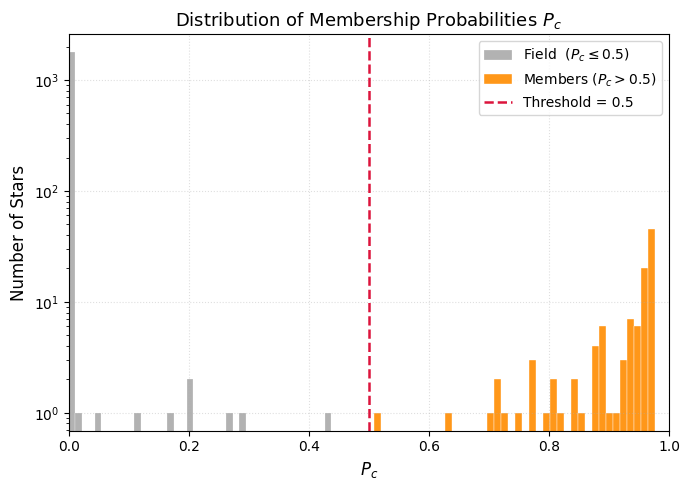

Figure saved as M41_probability_histogram.png


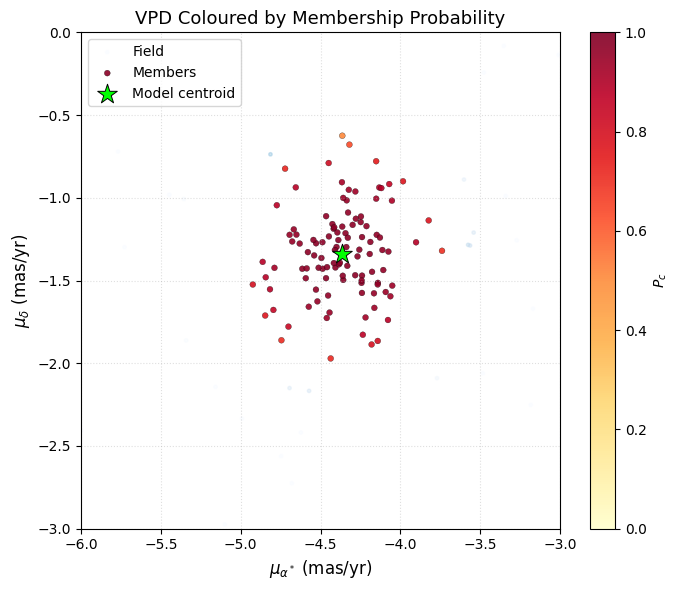

In [5]:
#histograma de probabilidades de membresía
fig1, ax1 = plt.subplots(figsize=(7, 5))

ax1.hist(P_c[mask_field],  bins=40, color='grey',      alpha=0.6,
         label=f'Field  ($P_c \\leq {umbral}$)', edgecolor='white', linewidth=0.3)
ax1.hist(P_c[mask_probables], bins=40, color='darkorange', alpha=0.9,
         label=f'Members ($P_c > {umbral}$)',    edgecolor='white', linewidth=0.3)
ax1.set_title(r'Distribution of Membership Probabilities $P_c$', fontsize=13)
ax1.set_xlabel(r'$P_c$', fontsize=12)
ax1.set_ylabel('Number of Stars', fontsize=12)
ax1.set_xlim(0, 1)
ax1.set_yscale('log')
ax1.axvline(umbral, color='crimson', lw=1.8, ls='--', label=f'Threshold = {umbral}')
ax1.legend(fontsize=10)
ax1.grid(linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('M41_probability_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as M41_probability_histogram.png")

# ── Figure 2: VPD Coloured by P_c ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 6))

sc = ax2.scatter(pm_ra[mask_field], pm_dec[mask_field],
                 c=P_c[mask_field], cmap='Blues', s=6, alpha=0.4,
                 vmin=0, vmax=1, label='Field')
sc2 = ax2.scatter(pm_ra[mask_probables], pm_dec[mask_probables],
                  c=P_c[mask_probables], cmap='YlOrRd', s=18, alpha=0.9,
                  vmin=0, vmax=1, edgecolors='black', linewidths=0.2, label='Members')
ax2.scatter(mu_xc, mu_yc, s=220, color='lime', marker='*',
            edgecolors='black', linewidths=0.7, zorder=6, label='Model centroid')
ax2.set_title('VPD Coloured by Membership Probability', fontsize=13)
ax2.set_xlabel(r'$\mu_{\alpha^*}$ (mas/yr)', fontsize=12)
ax2.set_ylabel(r'$\mu_{\delta}$ (mas/yr)', fontsize=12)
ax2.set_xlim(-6, -3)
ax2.set_ylim(-3, 0)
ax2.legend(fontsize=10)
ax2.grid(linestyle=':', alpha=0.4)
plt.colorbar(sc2, ax=ax2, label=r'$P_c$')

plt.tight_layout()
plt.savefig('M41_membership_VPD.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# ── Extract real Gaia photometry ───────────────────────────────────────────────
# These columns must exist in your Gaia query; adjust names if needed.
phot_cols = ['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'parallax']

# Check which photometric columns are present
available = [c for c in phot_cols if c in df_miembros.columns]
print("Photometric columns found:", available)

# Build arrays — drop rows with any NaN in photometric columns
df_phot = df_miembros[available].copy()
df_phot['P_c'] = P_c          # attach membership probability
df_phot.dropna(subset=available, inplace=True)

mag_G     = df_phot['phot_g_mean_mag'].values
color_BR  = (df_phot['phot_bp_mean_mag'] - df_phot['phot_rp_mean_mag']).values
prob      = df_phot['P_c'].values

# Membership mask on the cleaned photometry dataframe
is_member = prob > umbral

print(f"Stars with complete photometry : {len(df_phot)}")
print(f"Members with full photometry   : {np.sum(is_member)}")

Photometric columns found: ['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'parallax']
Stars with complete photometry : 1853
Members with full photometry   : 107


In [10]:
# ── Distance modulus from mean member parallax ─────────────────────────────────
par_members = df_phot.loc[is_member, 'parallax'].values
mean_plx    = np.median(par_members)   # median more robust than mean, as advised by professor
d_pc        = 1000.0 / mean_plx        # distance in parsecs
mu0         = 5.0 * np.log10(d_pc) - 5.0   # distance modulus (no extinction)

print(f"Median member parallax : {mean_plx:.4f} mas")
print(f"Estimated distance     : {d_pc:.1f} pc")
print(f"Distance modulus (μ₀)  : {mu0:.2f} mag  (no extinction correction)")

# Absolute magnitude (approximate — no reddening correction)
abs_mag_member = mag_G[is_member] - mu0

Median member parallax : 1.5734 mas
Estimated distance     : 635.6 pc
Distance modulus (μ₀)  : 9.02 mag  (no extinction correction)


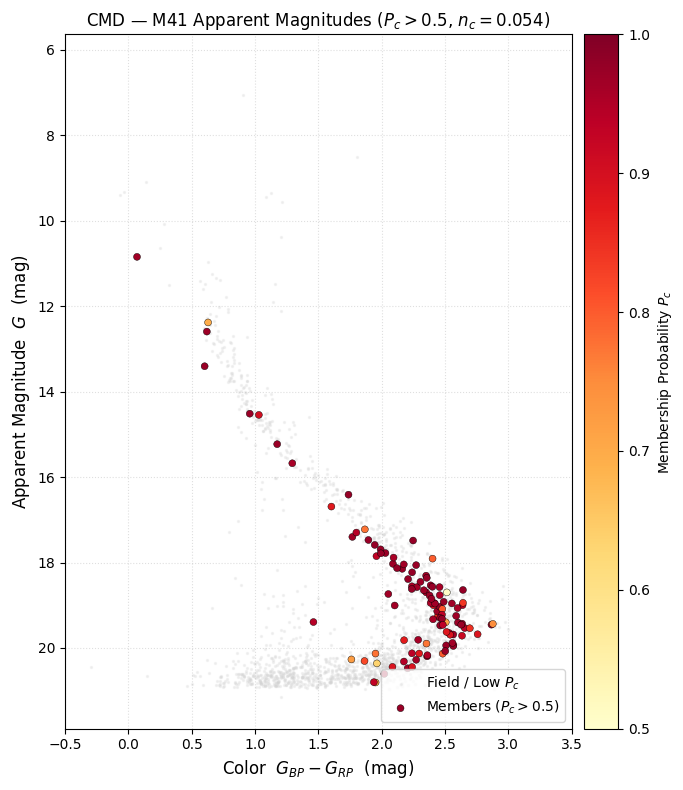

Figure saved as M41_CMD_apparent.png


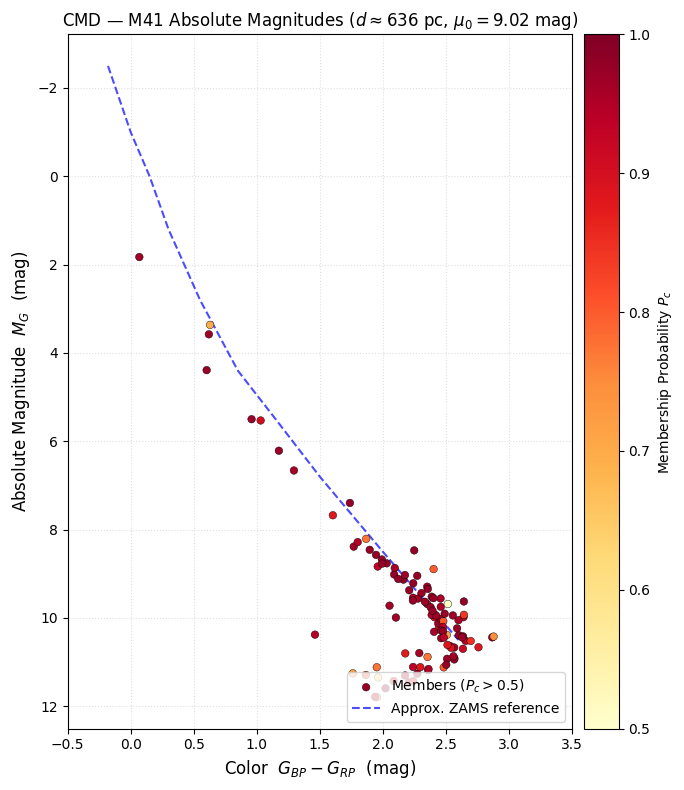

Figure saved as M41_CMD_absolute.png


In [11]:
# ── Figure 1: Apparent Magnitude CMD ──────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(7, 8))

ax.scatter(color_BR[~is_member], mag_G[~is_member],
           s=2, c='lightgrey', alpha=0.25, label='Field / Low $P_c$', zorder=1)

sc = ax.scatter(color_BR[is_member], mag_G[is_member],
                c=prob[is_member], cmap='YlOrRd',
                s=25, edgecolors='black', linewidths=0.3,
                label=f'Members ($P_c > {umbral}$)', zorder=3, vmin=0.5, vmax=1.0)

plt.colorbar(sc, ax=ax, label=r'Membership Probability $P_c$', pad=0.02)
ax.invert_yaxis()
ax.set_xlabel(r'Color  $G_{BP} - G_{RP}$  (mag)', fontsize=12)
ax.set_ylabel(r'Apparent Magnitude  $G$  (mag)', fontsize=12)
ax.set_title(f'CMD — M41 Apparent Magnitudes ($P_c > {umbral}$, $n_c = {n_c:.3f}$)', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(linestyle=':', alpha=0.4)
ax.set_xlim(-0.5, 3.5)

plt.tight_layout()
plt.savefig('M41_CMD_apparent.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as M41_CMD_apparent.png")

# ── Figure 2: Absolute Magnitude CMD ──────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 8))

sc2 = ax2.scatter(color_BR[is_member], abs_mag_member,
                  c=prob[is_member], cmap='YlOrRd',
                  s=30, edgecolors='black', linewidths=0.3,
                  label=f'Members ($P_c > {umbral}$)', zorder=3, vmin=0.5, vmax=1.0)

plt.colorbar(sc2, ax=ax2, label=r'Membership Probability $P_c$', pad=0.02)

zams_color = np.array([-0.18, 0.0, 0.15, 0.30, 0.55, 0.85, 1.15, 1.50, 2.00, 2.60])
zams_mag   = np.array([-2.5, -1.0,  0.0,  1.2,  2.8,  4.4,  5.5,  6.8,  8.5, 10.5])
ax2.plot(zams_color, zams_mag, 'b--', lw=1.5, alpha=0.7, label='Approx. ZAMS reference')

ax2.invert_yaxis()
ax2.set_xlabel(r'Color  $G_{BP} - G_{RP}$  (mag)', fontsize=12)
ax2.set_ylabel(r'Absolute Magnitude  $M_G$  (mag)', fontsize=12)
ax2.set_title(f'CMD — M41 Absolute Magnitudes ($d \\approx {d_pc:.0f}$ pc, $\\mu_0 = {mu0:.2f}$ mag)', fontsize=12)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(linestyle=':', alpha=0.4)
ax2.set_xlim(-0.5, 3.5)

plt.tight_layout()
plt.savefig('M41_CMD_absolute.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as M41_CMD_absolute.png")

In [12]:
# ── Summary Statistics of Members ─────────────────────────────────────────────
df_final_members = df_phot[is_member].copy()
df_final_members['abs_mag_G'] = abs_mag_member
df_final_members['color_BP_RP'] = color_BR[is_member]

print("=" * 55)
print("   SUMMARY — M41 Probable Members")
print("=" * 55)
print(f"  Total probable members        : {len(df_final_members)}")
print(f"  Median G magnitude            : {np.median(mag_G[is_member]):.2f} mag")
print(f"  Median BP-RP color            : {np.median(color_BR[is_member]):.3f} mag")
print(f"  Median parallax               : {mean_plx:.4f} mas")
print(f"  Estimated distance            : {d_pc:.1f} pc")
print(f"  Distance modulus (no ext.)    : {mu0:.2f} mag")
print(f"  Mean membership probability   : {np.mean(prob[is_member]):.4f}")
print("=" * 55)

df_final_members[['phot_g_mean_mag', 'color_BP_RP', 'abs_mag_G', 'parallax', 'P_c']].describe()

   SUMMARY — M41 Probable Members
  Total probable members        : 107
  Median G magnitude            : 19.00 mag
  Median BP-RP color            : 2.352 mag
  Median parallax               : 1.5734 mas
  Estimated distance            : 635.6 pc
  Distance modulus (no ext.)    : 9.02 mag
  Mean membership probability   : 0.9227


,phot_g_mean_mag,color_BP_RP,abs_mag_G,parallax,P_c
count,107.000000,107.000000,107.000000,107.000000,107.000000
mean,18.664125,2.197784,9.648371,1.581195,0.922707
std,1.747975,0.491488,1.747975,0.051870,0.084788
min,10.843549,0.068417,1.827794,1.500330,0.509069
25%,18.188893,2.041656,9.173139,1.535027,0.899383
50%,18.999969,2.351536,9.984215,1.573436,0.962968
75%,19.687695,2.486853,10.671940,1.619461,0.972703
max,20.808502,2.878571,11.792748,1.696776,0.977436
